# **Exercise 1**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = pd.read_csv("filtered-2012-24.csv",sep=";")
df_unfiltered = pd.read_csv("unfiltered-2023-24.csv",sep=";")

/tmp/ipykernel_48131/2399666426.py:6: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_filtered = pd.read_csv("filtered-2012-24.csv",sep=";")


# **Filtered DataFrame (13 years of data)**

In [2]:
df_filtered.head()

,id,date,day,month,year,time,timezone,from-domain,from-self,size-bytes,...,spam,spam-score,agent,zip,html,pdf,doc,ppt,calendar,image
0,"1346928835.6939_745.origin:2,S",18,Wed,Jul,2012,23:51:13,'+0530',iitb.ac.in,False,14651,...,False,-100.0,Mozilla/5.0 (X11; Linux x86_64; rv:13.0) Gecko...,False,True,False,False,False,False,False
1,"1346928827.6939_203.origin:2,S",02,Mon,Jul,2012,21:20:05,'+0530',iitb.ac.in,False,2757,...,False,-100.0,NOT FOUND,False,False,False,False,False,False,False
2,"1346928832.6939_533.origin:2,S",27,Fri,Jul,2012,12:08:17,'+0530',iitb.ac.in,False,6555,...,False,-100.0,NOT FOUND,False,False,False,False,False,False,False
3,"1346928842.6939_1221.origin:2,S",19,Sun,Aug,2012,05:14:22,'+0000',iitb.ac.in,False,4574,...,False,-100.0,NOT FOUND,False,False,False,False,False,False,False
4,"1346928825.6939_75.origin:2,S",25,Mon,Jun,2012,08:55:02,'+0530',iitb.ac.in,False,5059,...,False,-100.0,NOT FOUND,False,False,False,False,False,False,False


In [3]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84039 entries, 0 to 84038
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               84039 non-null  object 
 1   date             84039 non-null  object 
 2   day              84039 non-null  object 
 3   month            84039 non-null  object 
 4   year             84039 non-null  object 
 5   time             84039 non-null  object 
 6   timezone         84039 non-null  object 
 7   from-domain      84038 non-null  object 
 8   from-self        84039 non-null  bool   
 9   size-bytes       84039 non-null  int64  
 10  to-me            84039 non-null  bool   
 11  seminar          84039 non-null  bool   
 12  faculty-notices  84039 non-null  bool   
 13  discuss-faculty  84039 non-null  bool   
 14  spam             84039 non-null  bool   
 15  spam-score       84039 non-null  float64
 16  agent            84039 non-null  object 
 17  zip         

In [4]:
df_filtered.shape

(84039, 24)

# **Unfiltered DataFrame (last 2 years data)**

In [5]:
df_unfiltered.head()

,id,date,day,month,year,time,timezone,from-domain,from-self,size-bytes,...,spam,spam-score,agent,zip,html,pdf,doc,ppt,calendar,image
0,1736559943.M160578P514254Q11520R2e4b7370488e47...,17,Sun,Sep,2023,00:00:09,'+0530',iitb.ac.in,False,4133,...,False,-4.9,NOT FOUND,False,True,False,False,False,False,False
1,1736561544.M716932P527668Q24767R4ade6278d0a834...,12,Fri,Jul,2024,12:29:35,'-0400',GMAIL.COM,False,91167,...,False,-1.7,NOT FOUND,False,False,False,False,False,False,False
2,1736559355.M625357P509150Q6502R5040e9178e39c35...,26,Fri,May,2023,07:10:24,'+0530',iitb.ac.in,False,9615,...,False,-6.0,NOT FOUND,False,True,False,False,False,False,False
3,1736559980.M827052P514587Q11853R27171101d272bb...,23,Sat,Sep,2023,14:36:51,'+0000',polimi.it,False,16899,...,False,-2.0,NOT FOUND,False,True,False,False,False,False,False
4,1736560550.M180200P519430Q16667Raeabd6840bd99a...,10,Wed,Jan,2024,20:37:10,'+0100',IMT-ATLANTIQUE.FR,False,107311,...,False,-1.8,Mozilla Thunderbird,False,True,False,False,False,False,True


In [6]:
df_unfiltered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32691 entries, 0 to 32690
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               32691 non-null  object 
 1   date             32691 non-null  int64  
 2   day              32691 non-null  object 
 3   month            32691 non-null  object 
 4   year             32691 non-null  int64  
 5   time             32691 non-null  object 
 6   timezone         32691 non-null  object 
 7   from-domain      32691 non-null  object 
 8   from-self        32691 non-null  bool   
 9   size-bytes       32691 non-null  int64  
 10  to-me            32691 non-null  bool   
 11  seminar          32691 non-null  bool   
 12  faculty-notices  32691 non-null  bool   
 13  discuss-faculty  32691 non-null  bool   
 14  spam             32691 non-null  bool   
 15  spam-score       32691 non-null  float64
 16  agent            32691 non-null  object 
 17  zip         

In [7]:
df_unfiltered.shape

(32691, 24)

# **Pre-processing**

In [ ]:
def make_datetime(df):
    format_ = df['date'].astype(str) + ' ' + df['month'] + ' ' + df['year'].astype(str) + ' ' + df['time']
    return pd.to_datetime(format_, errors='coerce')

df_filtered['datetime'] = make_datetime(df_filtered)
df_unfiltered['datetime'] = make_datetime(df_unfiltered)

# after creating datetime column, we can drop these redundant columns
df_filtered.drop(columns=['date','month','year','time'], inplace=True)  
df_unfiltered.drop(columns=['date','month','year','time'], inplace=True)

In [9]:
df_filtered['day'].value_counts()

day
Wed          15013
Tue          14798
Mon          14749
Thu          14232
Fri          13185
Sat           5981
Sun           5474
NOT FOUND      607
Name: count, dtype: int64

In [10]:
df_unfiltered['day'].value_counts()

day
Wed          5895
Tue          5819
Mon          5764
Thu          5525
Fri          5351
Sat          2225
Sun          1944
NOT FOUND     168
Name: count, dtype: int64

**we need to obtain these "NOT FOUND" days from "datetime" column**

In [11]:
df_filtered['weekday'] = df_filtered['datetime'].dt.day_name()
df_unfiltered['weekday'] = df_unfiltered['datetime'].dt.day_name()

In [12]:
df_filtered['weekday'].shape

(84039,)

In [13]:
df_filtered['weekday'].value_counts()

weekday
Monday       14534
Wednesday    14340
Tuesday      13905
Thursday     13866
Friday       12948
Saturday      7602
Sunday        6823
Name: count, dtype: int64

In [14]:
df_unfiltered['weekday'].shape

(32691,)

In [15]:
df_unfiltered['weekday'].value_counts()

weekday
Monday       6014
Wednesday    5871
Tuesday      5537
Friday       5379
Thursday     5144
Saturday     2717
Sunday       2029
Name: count, dtype: int64

In [ ]:
# after obtaining weekday column, we can drop day column as it is redundant
df_filtered.drop(columns=['day'], inplace=True)  
df_unfiltered.drop(columns=['day'], inplace=True)

## **Now we are ready to answer the questions**

# Question 1 

In [17]:
df_unfiltered.head()

,id,timezone,from-domain,from-self,size-bytes,to-me,seminar,faculty-notices,discuss-faculty,spam,...,agent,zip,html,pdf,doc,ppt,calendar,image,datetime,weekday
0,1736559943.M160578P514254Q11520R2e4b7370488e47...,'+0530',iitb.ac.in,False,4133,True,False,False,False,False,...,NOT FOUND,False,True,False,False,False,False,False,2023-09-17 00:00:09,Sunday
1,1736561544.M716932P527668Q24767R4ade6278d0a834...,'-0400',GMAIL.COM,False,91167,False,False,False,False,False,...,NOT FOUND,False,False,False,False,False,False,False,2024-07-12 12:29:35,Friday
2,1736559355.M625357P509150Q6502R5040e9178e39c35...,'+0530',iitb.ac.in,False,9615,False,False,False,False,False,...,NOT FOUND,False,True,False,False,False,False,False,2023-05-26 07:10:24,Friday
3,1736559980.M827052P514587Q11853R27171101d272bb...,'+0000',polimi.it,False,16899,True,False,False,False,False,...,NOT FOUND,False,True,False,False,False,False,False,2023-09-23 14:36:51,Saturday
4,1736560550.M180200P519430Q16667Raeabd6840bd99a...,'+0100',IMT-ATLANTIQUE.FR,False,107311,False,False,False,False,False,...,Mozilla Thunderbird,False,True,False,False,False,False,True,2024-01-10 20:37:10,Wednesday


In [18]:
emails_per_day = df_unfiltered.groupby('weekday').size()
unique_days = df_unfiltered['datetime'].dt.date.nunique()
daily_avg = emails_per_day / unique_days
daily_avg

weekday
Friday       7.249326
Monday       8.105121
Saturday     3.661725
Sunday       2.734501
Thursday     6.932615
Tuesday      7.462264
Wednesday    7.912399
dtype: float64

In [19]:
weekday_avg = daily_avg.loc[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

weekday_variance = weekday_avg.var()
weekday_range = weekday_avg.max() - weekday_avg.min()

print("Weekday Variance:", weekday_variance)
print("Weekday Range:", weekday_range)

Weekday Variance: 4.697265851364194
Weekday Range: 5.3706199460916455


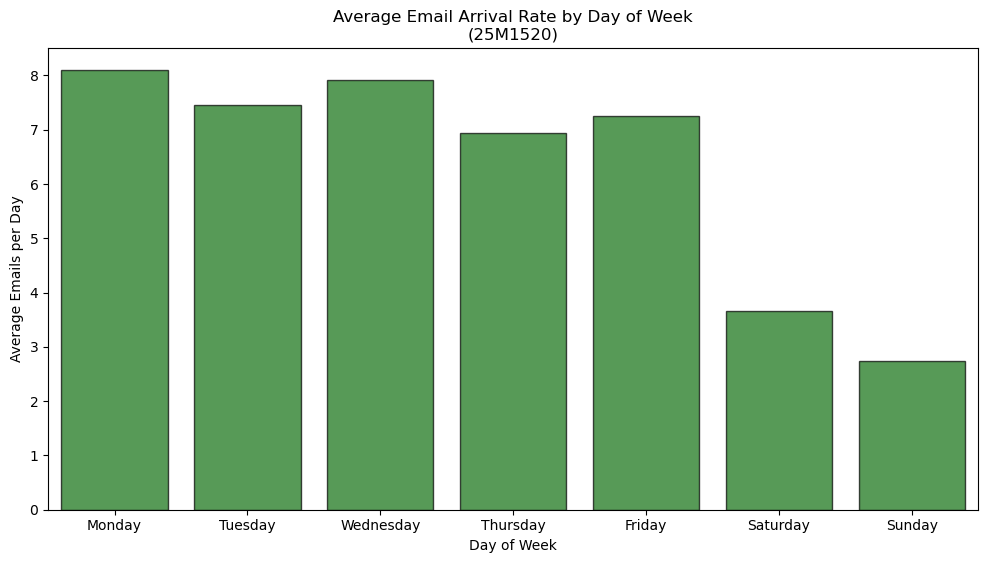

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values, color='green', alpha=0.7, edgecolor='black')

plt.title('Average Email Arrival Rate by Day of Week\n(25M1520)')
plt.xlabel('Day of Week')
plt.ylabel('Average Emails per Day')
plt.show()

**Email volume varies notably by day of the week. Weekdays receive significantly more emails than weekends, with Monday showing the highest average arrival rate. In contrast, Sunday has the lowest email traffic.**

# Question 2

(a) Time at which email is Sent
Header: "Date:"

(b) Spam Score
Header: "X-Spam-Score:"

# Question 3

Header Appearing More Than Once: "Received:"

Explanation: Each mail server that handles an email adds a "Received:" header.
Together, these headers form a chain that shows the complete route the email took, from the sender’s server to the recipient’s server, in reverse order (latest at the top).

# Question 4

**I'm working with updated df_filtered (few columns were dropped in preprocessing step)**

In [21]:
df_filtered_2324 = df_filtered[df_filtered['datetime'].dt.year.isin([2023, 2024])]

fraction_deleted = 1 - len(df_filtered_2324) / len(df_unfiltered)
fraction_deleted

0.618916521366737

**After aligning both datasets to 2023–2024, about 62% of emails were deleted and 38% were retained.**

# Question 5

In [22]:
html_df_filtered = df_filtered['html'].mean()
html_df_unfiltered = df_unfiltered['html'].mean()

print("Average HTML content in filtered dataset:", html_df_filtered)
print("Average HTML content in unfiltered dataset:", html_df_unfiltered)

Average HTML content in filtered dataset: 0.5776127750211212
Average HTML content in unfiltered dataset: 0.7866691138233765


**HTML emails make up about 79% of the unfiltered dataset but only 58% of the retained emails, indicating that HTML emails are more likely to be deleted.**

# Question 6

In [23]:
cols_with_attachment = ['pdf', 'doc', 'ppt', 'image']

df_filtered['has_attachment'] = df_filtered[cols_with_attachment].any(axis=1)
df_unfiltered['has_attachment'] = df_unfiltered[cols_with_attachment].any(axis=1)

filtered_attach_rate = df_filtered['has_attachment'].mean()
unfiltered_attach_rate = df_unfiltered['has_attachment'].mean()

print("Attachment Rate in Filtered Dataset:", filtered_attach_rate)
print("Attachment Rate in Unfiltered Dataset:", unfiltered_attach_rate)

Attachment Rate in Filtered Dataset: 0.13173645569319006
Attachment Rate in Unfiltered Dataset: 0.10856198953840507


**Emails with attachments account for about 11% of all emails but 13% of retained emails, indicating no bias against attachments; such emails are more likely to be kept.**

# Question 7

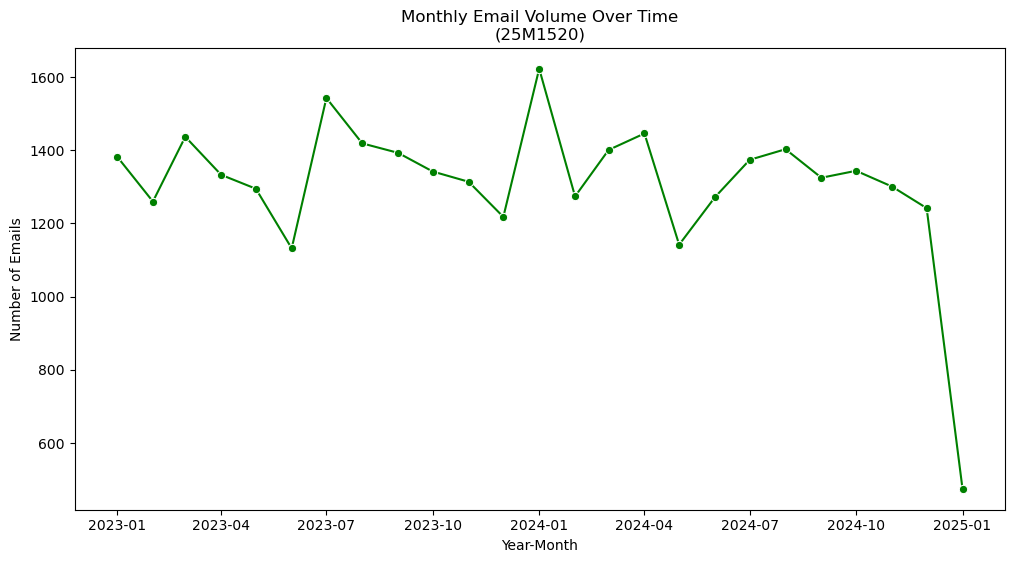

In [24]:
df_unfiltered['year_month'] = df_unfiltered['datetime'].dt.to_period('M')
monthly_counts = df_unfiltered.groupby('year_month').size()

monthly_counts_df = monthly_counts.reset_index()
monthly_counts_df.columns = ['year_month', 'count']
monthly_counts_df['year_month'] = monthly_counts_df['year_month'].dt.to_timestamp()

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_counts_df['year_month'], y=monthly_counts_df['count'], marker='o', color='green')

plt.title('Monthly Email Volume Over Time\n(25M1520)')
plt.xlabel('Year-Month')
plt.ylabel('Number of Emails')
plt.show()

**The monthly email volume fluctuates over time without a clear long-term upward or downward trend. Most months consistently receive around 1,200–1,600 emails. The sharp decline in the final month is likely due to incomplete data rather than an actual reduction in email activity.**

# Question 8

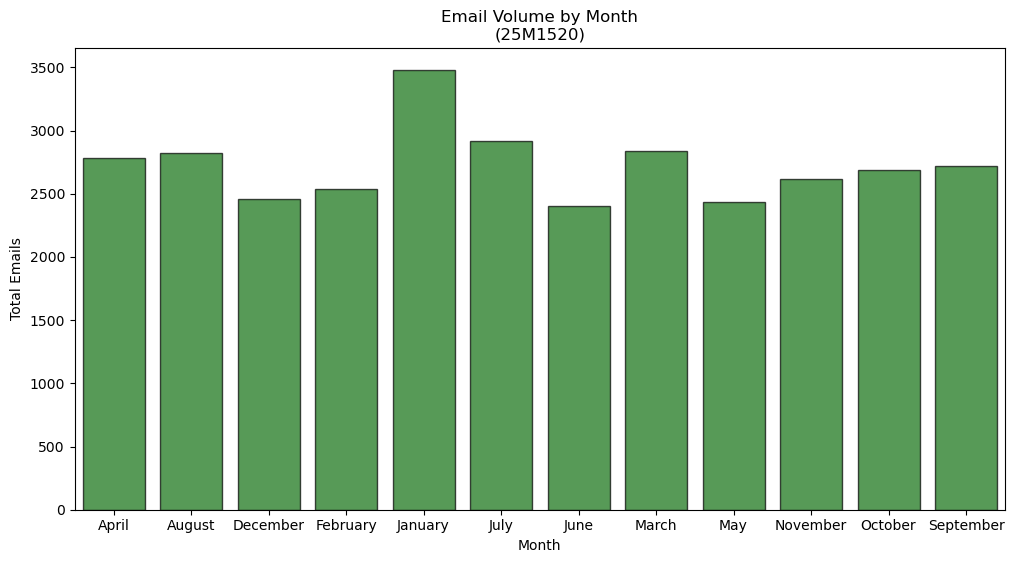

In [ ]:
df_unfiltered['month_name'] = df_unfiltered['datetime'].dt.month_name()
month_counts = df_unfiltered.groupby('month_name').size()

plt.figure(figsize=(12,6))
sns.barplot(x=month_counts.index, y=month_counts.values, color='green', alpha=0.7, edgecolor='black')

plt.title('Email Volume by Month\n(25M1520)')
plt.xlabel('Month')
plt.ylabel('Total Emails')
plt.show()

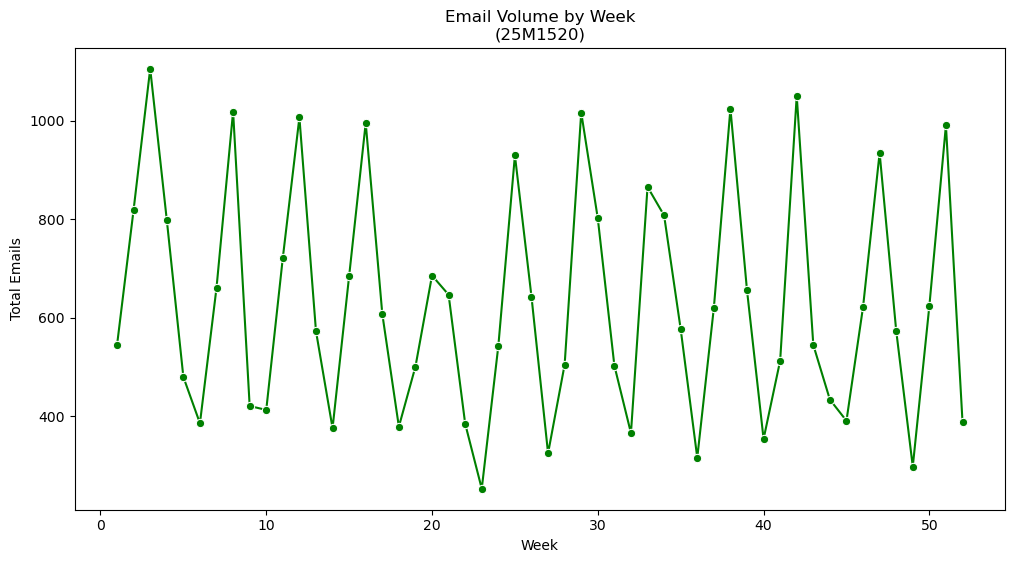

In [26]:
df_unfiltered['week'] = df_unfiltered['datetime'].dt.isocalendar().week
week_counts = df_unfiltered.groupby('week').size()

plt.figure(figsize=(12,6))
sns.lineplot(data=week_counts.reset_index().rename(columns={0: 'count'}), x='week', y='count', marker='o', color='green')

plt.title('Email Volume by Week\n(25M1520)')
plt.xlabel('Week')
plt.ylabel('Total Emails')
plt.show()

**Email traffic peaks in January, with high activity also in March, July, and August, aligning with academic schedules. Weekly patterns show periodic spikes, likely due to deadlines, exams, and seminars.**

# Question 9 

(a) Emails Expected on Coming Monday

In [27]:
monday_avg = daily_avg['Monday']
print("Average number of emails received on Mondays:", monday_avg)

Average number of emails received on Mondays: 8.10512129380054


(b) Emails Expected in Coming Week (Mon–Sun)

In [28]:
weekly_forecast = daily_avg.sum()
print("Projected weekly email volume:", weekly_forecast)

Projected weekly email volume: 44.05795148247979


**Historical averages suggest about 8 emails on the coming Monday and around 44 emails for the entire coming week.**